### testing ground

In [376]:
import numpy as np
import pandas as pd
import networkx as nx
import functions_regular as fnr
import functions_subtrees as fns
import matplotlib.pyplot as plt
import importlib
import numpy.lib.recfunctions as rfn
import cProfile as cp
import random as rnd
import math
importlib.reload(fnr)
importlib.reload(fns)

# G = parseStringToGraph('[[0,1], [1,2], [2,0], [4,2], [3,4], [5,4], [6,4], [7,4]]')
# H = parseStringToGraph('[[0,1], [1,2], [2,0], [4,2], [3,4], [5,4], [6,4], [7,4]]')
# G = nx.scale_free_graph(50, seed=1)
# G = nx.to_undirected(G)
# H = nx.scale_free_graph(5, seed=0)
# H = nx.to_undirected(H)

######################################################################

T = fns.randomTree(5, 0)
S = fns.randomTree(10, 0)

# T = parseStringToGraph('[[0,1], [0,2], [3,0], [4,0]]')
# S = parseStringToGraph('[[0,1], [0,2], [3,0], [4,0]]')
K = nx.Graph()
K.add_edges_from(T.edges())
aut = fnr.findSubgraphInstances(T, K, False)
M = fnr.symmetryConditions(aut)

# print(M)


instances = fns.findSubgraphInstances(T, S, True)
print(len(instances))

NetworkXError: The edge 4-5 is not in the graph

In [368]:
fns.countRootedSubtrees(T, 9, S, 48)

792.0

In [369]:
f = fnr.Map([(9,48)])
len(fnr.isomorphicExtensions(f, T, S, 0, M))

792

In [ ]:
A = fns.randomTree(15, 1)
nx.draw(A, with_labels=True)
fns.compressTree(A, 14, 14)

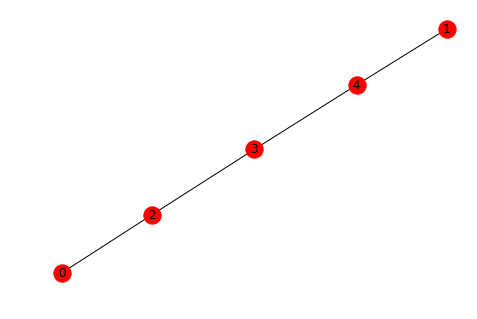

In [377]:
nx.draw(T, with_labels=True)

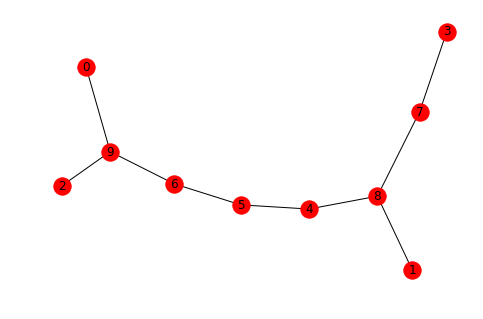

In [378]:
nx.draw(S, with_labels=True)

In [ ]:
from matplotlib.pyplot import figure

G = nx.scale_free_graph(50, seed=21)
G = nx.to_undirected(G)

figure(num=None, figsize=(10, 10), dpi=80, facecolor='w', edgecolor='k')
plt.axis('off')
nx.draw_networkx(G, with_labels=True, node_size=0)


In [375]:
file = 'test_data/tests.txt'

test_findSubgraphInstances(file, 'subtrees')

Test: triangle vs itself
H: [[0,1], [1,2], [0,2]] 
G: [[0,1], [1,2], [0,2]] 
correct number of instances: 1
instances found: 1
succeeded

Test: triangle in triangle-plus-line
H: [[0,1], [1,2], [0,2]]
G: [[1,2], [2,3], [1,3], [0,1]]
correct number of instances: 1
instances found: 1
succeeded

Test: triangle-plus-line in triangle:
H: [[1,2], [2,3], [1,3], [0,1]]
G: [[0,1], [1,2], [0,2]]
correct number of instances: 0
instances found: 0
succeeded

Test: triangle-plus-line vs itself
H: [[0,1], [0,2], [1,2], [0,3]]
G: [[1,2], [2,3], [1,3], [0,1]]
correct number of instances: 1
instances found: 1
succeeded

Test: triangle in square-with-diagonal
H: [[0,1], [1,2], [0,2]]
G: [[0,1], [1,2], [2,3], [3,0], [0,2]]
correct number of instances: 2
instances found: 2
succeeded

Test: square vs square-with-diagonal
H: [[0,1], [1,2], [2, 3], [3,0]]
G: [[0,1], [1,2], [2,3], [3,0], [0,2]]
correct number of instances: 0
instances found: 0
succeeded

Test: square vs itself
H: [[0,1], [1,2], [2, 3], [3,0]]
G

In [45]:
# input: edges of a graph written in bracketed pairs
# output: graph with corresponding edges
def parseStringToGraph(s):
    l = []
    
    if(s[len(s)-1] == ' '):
        s = s[:-1]
    
    if(s[0] == '[' and s[len(s)-1] == ']'):
        s = s[-(len(s)-1):-1]
        start = [key for key, val in enumerate(s) if val == '[']
        end = [key for key, val in enumerate(s) if val == ']']
        comma = [key for key, val in enumerate(s) if (val == ',' and not s[key-1] == ']')]
        
        for i in range(len(start)):
            left = [v for k, v in enumerate(s) if k in range(start[i]+1, comma[i])]
            right = [v for k, v in enumerate(s) if k in range(comma[i]+1, end[i])]
            
            left = int(''.join(left))
            right = int(''.join(right))
            l.append((left, right))
    
    H = nx.Graph()
    H.add_edges_from(l)
    
    return H


# reads the text file output by Josh and returns test name, hstring,
# gstring and answer in a dict
def parseFileToDict(file):
    f = open(file, 'r')
    D = {}
    index = 0
    first = True
    
    for line in f:
        if (line[0:4] == 'Test'):
            title = line[:-1]
            
        if (line[0] == '['):
            if (first):
                hstring = line[:-1]
                first = False
            else:
                gstring = line[:-1]
                first = True
            
            
        if (ord(line[0]) >= 48 and ord(line[0]) <= 57):
            ans = int(line)
            D[index] = {'title': title,
                        'hstring': hstring,
                        'gstring': gstring,
                        'answer': ans}
            index = index + 1
    
    return D


def test_findSubgraphInstances(file, which='regular'):
    
    D = parseFileToDict(file)
    
    for key in D.keys():
        print(D[key]['title'])
        H = nx.Graph()
        G = nx.Graph()
        
        hGraph = parseStringToGraph(D[key]['hstring'])
        gGraph = parseStringToGraph(D[key]['gstring'])
        
        H.add_edges_from(hGraph.edges())
        G.add_edges_from(gGraph.edges())
        
        if (which == 'regular'):
            count = fnr.findSubgraphInstances(H, G, True)
            
        if (which == 'subtrees'):
            count = fns.findSubgraphInstances(H, G, True)
        
        l = count
        ans = D[key]['answer']
        
        print('H: ',end='')
        print(D[key]['hstring'])
        print('G: ',end='')
        print(D[key]['gstring'])
#         print('instances: ',end='')
#         print([tuple(i.getMap()) for i in instances])
        print('correct number of instances: ',end='')
        print(ans)
        print('instances found: ',end='')
        print(l)
        
        if(l == ans):
            print('succeeded')
        else:
            print('failed')
            
        print()
        
        